In [4]:
!pip install torch

  Using cached torch-2.10.0-cp312-cp312-win_amd64.whl.metadata (31 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached setuptools-82.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached markupsafe-3.0.3-cp312-cp312-win_amd64.whl.metadata (2.8 kB)
Using cached torch-2.10.0-cp312-cp312-win_amd64.whl (113.8 MB)
Using cached fsspec-2026.2.0-py3-none-any.whl (202 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached setuptools-82.0.0-py3-none-any.whl (1.0 


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: C:\Users\archi\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip



[Accuracy Evaluation] Calculating Predictive Power...
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
497
4

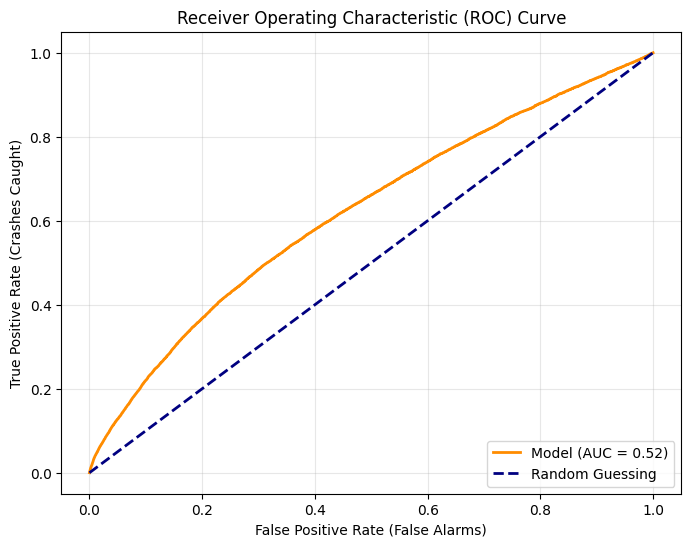


Sample Successful 'Bubble Bursts' Predicted:
      Date          Stock   Signal  Return_Next_Month
2020-02-14 MSFT UW Equity 0.862790          -0.187375
2020-02-14 AAPL UW Equity 0.852710          -0.180889
2020-02-14   BA UN Equity 0.782734          -0.332814
2020-02-19  TKO UN Equity 1.000000          -0.303955
2020-02-19 TSLA UW Equity 0.903071          -0.388993
2020-02-19 MSFT UW Equity 0.887038          -0.257475
2020-02-19 AAPL UW Equity 0.863924          -0.232958
2020-02-19   BA UN Equity 0.787154          -0.542300
2020-02-20  TKO UN Equity 1.000000          -0.248848
2020-02-20  ALB UN Equity 0.841125          -0.278868


In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, precision_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch

def evaluate_predictive_power(test_results, prices, forward_window=22, crash_threshold=-0.10):
    """
    Calculates accuracy by checking if high signals actually lead to price drops.
    Args:
        forward_window: Days to look ahead (e.g., 22 days = 1 month)
        crash_threshold: Return threshold to define a 'Real Crash' (e.g., -0.10 means -10% drop)
    """
    print("\n[Accuracy Evaluation] Calculating Predictive Power...")
    
    # List to track specific successful predictions for debugging
    successful_calls = []
    
    sorted_dates = sorted(list(test_results.keys()))
    
    # We stop early so we have enough data for the forward window
    valid_dates = [d for d in sorted_dates if d <= prices.index[-1] - pd.Timedelta(days=forward_window*1.5)]
    records = []
    for t in valid_dates:
        stocks = test_results[t]["stocks"]
        signals = test_results[t]["signals"]
        if isinstance(signals, torch.Tensor):
            signals = signals.cpu().numpy()
        #signals = signals.flatten()
        # Calculate Forward Returns for these stocks
        # Get price at t
        # Keep only stocks that exist in prices
        available = [s for s in stocks if s in prices.columns]

        if len(available) == 0:
            continue

        # Align signals
        mask = [i for i, s in enumerate(stocks) if s in available]
        aligned_signals = signals[mask]

        p_t = prices.loc[t, available]

        future_idx = prices.index.searchsorted(t + pd.Timedelta(days=forward_window))
        if future_idx >= len(prices):
            continue

        future_date = prices.index[future_idx]
        p_future = prices.loc[future_date, available]

        
        # Return calculation
        fwd_returns = (p_future - p_t) / p_t
        is_crash = (fwd_returns < crash_threshold).astype(int)

        # for i, stock in enumerate(available):
        #     y_true.append(is_crash.iloc[i])
        #     y_scores.append(aligned_signals[i])

        uncertainties = np.array(test_results[t]["uncertainties"])[mask]

        for i, stock in enumerate(available):
            records.append({
                "date": t,
                "stock": stock,
                "signal": aligned_signals[i],
                "uncertainty": uncertainties[i],
                "return": fwd_returns.iloc[i],
                "crash": is_crash.iloc[i]

            })

        # Track Top Predictions
        # Combine into dataframe
        df_eval = pd.DataFrame({
        'Stock': available,
        'Signal': aligned_signals,
        'Return': fwd_returns.values,
        'Crash': is_crash.values
        })
        #df_eval = pd.DataFrame({'Stock': stocks, 'Signal': signals, 'Return': fwd_returns, 'Crash': is_crash})
        top_picks = df_eval.sort_values('Signal', ascending=False).head(5)
        
        for _, row in top_picks.iterrows():
            if row['Crash'] == 1:
                successful_calls.append({
                    'Date': t.strftime('%Y-%m-%d'),
                    'Stock': row['Stock'],
                    'Signal': row['Signal'],
                    'Return_Next_Month': row['Return']
                })
    df_all = pd.DataFrame(records)

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)
    # Can the model distinguish between a crash and normal price action?
    auc = roc_auc_score(df_all["crash"], df_all["uncertainty"])

    # auc = roc_auc_score(df_all["crash"], df_all["signal"])
    
    # --- METRIC 2: Information Coefficient (IC) ---
    # Correlation between Signal and Crash Probability
    # Ideally Positive (Higher Signal = Higher Probability of Crash)
    ic = df_all["signal"].corr(df_all["return"], method="spearman")


    # --- METRIC 3: Precision @ Top 10% ---
    # If we take the top 10% highest signals, what % were actually crashes?
    #threshold_top_10 = np.percentile(y_scores, 90)
    #high_signal_indices = y_scores > threshold_top_10
    
    #precision_top_10 = np.mean(y_true[high_signal_indices]) # % of high signals that were crashes
    #baseline_crash_rate = np.mean(y_true) # % of ALL stocks that crashed
    baseline_crash_rate = df_all["crash"].mean()

    # Lift: How much better is the model than random chance?
    #lift = precision_top_10 / baseline_crash_rate if baseline_crash_rate > 0 else 0
    
    # print("-" * 60)
    print(f"PREDICTIVE ACCURACY (Forward Window: {forward_window} days, Crash Threshold: {crash_threshold*100}%)")
    print("-" * 60)
    print(f"1. AUC-ROC Score:      {auc:.4f}  (0.5 = Random, >0.6 = Good, >0.7 = Excellent)")
    print(f"2. Info Coefficient:   {ic:.4f}   (Correlation with actual crashes)")
    # print(f"3. Precision (Top 10%):{precision_top_10:.2%} (Of highest signals, this % actually crashed)")
    # print(f"4. Baseline Crash Rate:{baseline_crash_rate:.2%} (Random probability of a crash)")
    # print(f"5. Model Lift:         {lift:.2f}x    (Model is {lift:.1f} times better than random guessing)")
    # print("-" * 60)
    
    # --- Visualization: ROC Curve ---
    fpr, tpr, _ = roc_curve(df_all["crash"], df_all["signal"])

    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"Model (AUC = {auc:.2f})", color='darkorange', lw=2)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')
    plt.xlabel('False Positive Rate (False Alarms)')
    plt.ylabel('True Positive Rate (Crashes Caught)')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    
    print("\nSample Successful 'Bubble Bursts' Predicted:")
    print(pd.DataFrame(successful_calls).head(10).to_string(index=False))

# ==============================================================================
# EXECUTION
# ==============================================================================

    # Evaluate 1-Month Forward Accuracy looking for -15% Drops
test_results = pd.read_pickle('outputs/test_results_vae.pkl')
test_prices = pd.read_pickle('outputs/test_prices_vae.pkl')
#    results = {
    #     d: {
    #         'stocks': active_lists[i],
    #         'signals': all_signals[i],
    #         'uncertainties': all_uncertainties[i],
    #         'kl_loss': all_kl_losses[i]
    #     } 
    #     for i, d in enumerate(valid_dates)
    # }
evaluate_predictive_power(test_results, test_prices, forward_window=22, crash_threshold=-0.15)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr
import torch


def build_panel(test_results, prices, forward_window, crash_threshold):

    records = []

    sorted_dates = sorted(test_results.keys())

    valid_dates = [
        d for d in sorted_dates
        if d <= prices.index[-1] - pd.Timedelta(days=forward_window)
    ]

    for t in valid_dates:

        stocks = test_results[t]["stocks"]
        signals = np.array(test_results[t]["signals"])
        uncertainties = np.array(test_results[t]["uncertainties"])
        available = [s for s in stocks if s in prices.columns]

        if len(available) == 0:
            continue

        mask = [i for i, s in enumerate(stocks) if s in available]

        signals = signals[mask]

        uncertainties = uncertainties[mask]

        p_t = prices.loc[t, available]

        future_idx = prices.index.searchsorted(
            t + pd.Timedelta(days=forward_window)
        )

        if future_idx >= len(prices):
            continue

        future_date = prices.index[future_idx]
        p_future = prices.loc[future_date, available]
        fwd_returns = (p_future - p_t) / p_t
        crash = (fwd_returns < crash_threshold).astype(int)

        for i, stock in enumerate(available):

            records.append({
                "date": t,
                "stock": stock,
                "signal": signals[i],
                "uncertainty": uncertainties[i],
                "return": fwd_returns.iloc[i],
                "crash": crash.iloc[i]
            })

    return pd.DataFrame(records)



def evaluate_panel(df):

    if len(df) == 0:
        return None

    auc_signal = roc_auc_score(df["crash"], df["signal"])
    auc_uncertainty = roc_auc_score(df["crash"], df["uncertainty"])
    ic = spearmanr(df["signal"], df["return"]).correlation
    crash_rate = df["crash"].mean()

    return {
        "AUC_signal": auc_signal,
        "AUC_uncertainty": auc_uncertainty,
        "IC": ic,
        "CrashRate": crash_rate
    }



def grid_search(test_results, prices,
                forward_windows,
                crash_thresholds):

    results = []

    for fw in forward_windows:

        for ct in crash_thresholds:

            df = build_panel(
                test_results,
                prices,
                fw,
                ct
            )

            metrics = evaluate_panel(df)

            if metrics is None:
                continue

            metrics["ForwardWindow"] = fw

            metrics["CrashThreshold"] = ct

            results.append(metrics)

            print(
                f"FW={fw}, CT={ct:.2f} | "
                f"AUC_signal={metrics['AUC_signal']:.3f} | "
                f"AUC_uncertainty={metrics['AUC_uncertainty']:.3f} | "
                f"IC={metrics['IC']:.3f}"
            )

    return pd.DataFrame(results)


In [ ]:
test_results = pd.read_pickle("outputs/test_results_vae.pkl")

test_prices = pd.read_pickle("outputs/test_prices_vae.pkl") 
#FW=5, CT=-0.20 | AUC_signal=0.695 | AUC_uncertainty=0.528 | IC=0.019 for VAE

forward_windows = [5, 10, 22, 44, 66]

crash_thresholds = [-0.05, -0.10, -0.15, -0.20]


df_results = grid_search(
    test_results,
    test_prices,
    forward_windows,
    crash_thresholds
)

print(df_results.sort_values("AUC_signal", ascending=False))


TypeError: tuple indices must be integers or slices, not str

In [62]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
import torch


def evaluate_once(
        test_results,
        prices,
        forward_window,
        crash_threshold
):

    y_true = []
    y_scores = []

    sorted_dates = sorted(test_results.keys())

    valid_dates = [
        d for d in sorted_dates
        if d <= prices.index[-1] - pd.Timedelta(days=forward_window)
    ]

    for t in valid_dates:

        stocks, signals, uncertainties = test_results[t]['stocks'], test_results[t]['signals'], test_results[t]['uncertainties']

        if isinstance(signals, torch.Tensor):
            signals = signals.cpu().numpy()

        signals = signals.flatten()

        available = [s for s in stocks if s in prices.columns]

        if len(available) == 0:
            continue

        mask = [i for i,s in enumerate(stocks) if s in available]

        signals = signals[mask]

        p_t = prices.loc[t, available]

        future_idx = prices.index.searchsorted(
            t + pd.Timedelta(days=forward_window)
        )

        if future_idx >= len(prices):
            continue

        future_date = prices.index[future_idx]
        p_future = prices.loc[future_date, available]
        fwd_returns = (p_future - p_t) / p_t

        crash1 = (fwd_returns < crash_threshold).astype(int)
        crash2 = (uncertainties < 0.3).astype(int)
        crash = (crash1+crash2)/2
        y_true.extend(crash.values)
        y_scores.extend(signals)

    if len(y_true) == 0:
        return None

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)

    auc = roc_auc_score(y_true, y_scores)
    baseline = y_true.mean()
    precision = y_true[y_scores > np.percentile(y_scores, 90)].mean()
    lift = precision / baseline if baseline > 0 else np.nan
    return auc, lift, baseline

def grid_search(
        test_results,
        prices,
        forward_windows,
        crash_thresholds
):

    rows = []

    for fw in forward_windows:

        for ct in crash_thresholds:

            result = evaluate_once(
                test_results,
                prices,
                fw,
                ct
            )

            if result is None:
                continue

            auc, lift, baseline = result

            rows.append({
                "ForwardWindow": fw,
                "CrashThreshold": ct,
                "AUC": auc,
                "Lift": lift,
                "Baseline": baseline
            })

            print(
                f"FW={fw:3d} "
                f"CT={ct:6.2f} "
                f"AUC={auc:.3f} "
                f"Lift={lift:.2f}"
            )

    return pd.DataFrame(rows)


In [63]:
forward_windows = [5,10,22,44,66,120]
crash_thresholds = [-0.05,-0.10,-0.15,-0.20,-0.30]

test_results = pd.read_pickle("outputs/test_results_vae.pkl")
test_prices = pd.read_pickle("outputs/test_prices_vae.pkl") 

df_results = grid_search(
    test_results,
    test_prices,
    forward_windows,
    crash_thresholds
)


ValueError: continuous format is not supported

In [50]:
df_results.sort_values("AUC", ascending=False)


,ForwardWindow,CrashThreshold,AUC,Lift,Baseline
24,66,-0.30,0.601872,1.703410,0.008001
29,120,-0.30,0.591085,1.391929,0.014462
18,44,-0.20,0.577449,1.422556,0.021704
23,66,-0.20,0.575472,1.309060,0.031411
17,44,-0.15,0.569101,1.256855,0.048432
19,44,-0.30,0.567846,1.706008,0.005885
3,5,-0.20,0.563132,1.573797,0.002467
22,66,-0.15,0.561330,1.221412,0.065040
12,22,-0.15,0.560349,1.320311,0.027894
2,5,-0.15,0.559464,1.390892,0.005669
